# Phage genome analysis

In order to look for enrichment of certain nucleotides in the spacer seqeucens we need to work out the baseline properties of the phage genome, then we can look at the relative differences between the spacer seqeucnes  that are integrated into the CRISPR array veruses the rest of the phage genomes that did not get intgrated.<br>

Perform blast search of all the spacer sequences in the preliminary analysis and see what have a hit in the NCBI database.<br>

First try to blast the spacer sequences against the core_nt database, which is a reduced version of NCBI nt database.

In [1]:
import sys, os
import pandas as pd
import numpy as np
import json
import subprocess
from pathlib import Path
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import modules.analysis_utils as analysis_utils
import modules.database_utils as db_utils
from concurrent.futures import ProcessPoolExecutor
import modules.blast_utils as blast_utils
from modules.blast_utils import PhageBlast
from IPython.display import display
from plotnine import (ggplot, aes, geom_histogram, geom_density, theme_bw, 
                      labs, theme, element_text, scale_x_continuous, geom_vline, 
                      geom_boxplot, geom_jitter, scale_x_discrete, stat_summary,
                      scale_y_continuous)
import matplotlib.pyplot as plt
from modules.analysis_utils import PhageElement

In [ ]:
def subprocess_run(cmd):
    """
    Run a subprocess command and check for errors.
    """
    try:
        print(f"Running command: {' '.join(cmd)}")
        subprocess.run(cmd, check=True)
    except subprocess.CalledProcessError as e:
        print(f"Error during command execution: {e}")
        sys.exit(1)

In [ ]:
core_nt_path = '/core_nt/'

core_nt_json = json.load(open(f"{core_nt_path}/core_nt-nucl-metadata.json"))
files_url = core_nt_json["files"]
for url in files_url:
    # Download the file and extract it
    wget_cmd = ["wget", "-P", core_nt_path, url]
    subprocess_run(wget_cmd)
    file_path = os.path.join(core_nt_path, os.path.basename(url))
    tar_cmd = ["tar", "-xvzf", file_path, "-C", core_nt_path]
    subprocess_run(tar_cmd)
    # Remove the tar file after extraction
    rm_cmd = ["rm", file_path]
    subprocess_run(rm_cmd)

['ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.00.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.01.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.02.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.03.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.04.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.05.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.06.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.07.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.08.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.09.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.10.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.11.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.12.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.13.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.14.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.15.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/blast/db/core_nt.16.tar.gz', 'ftp://ftp.ncbi.nlm.nih.gov/bl

Blast spacer sequences against core nt database

In [ ]:
array_df = db_utils.read_table_from_db("prelim/analysis/preliminary_crisprs.csv")
spacer_df = db_utils.read_table_from_db("prelim/analysis/all_spacers.csv")
output_dir = Path(f"/spacers_db/blastn_results/")

array_filt = array_df.drop_duplicates(subset=['array_id'])
array_filt = array_filt[
    (array_filt['category'] != 'Alternative') &
    (array_filt['spacer_len_var'] < 1) &
    (array_filt['filter'] == 'PASSED')
]

filt_seqs = spacer_df[spacer_df['array_id'].isin(array_filt['array_id'])]

seq_with_species = filt_seqs.merge(
    array_df[['array_id', 'speciesname', 'biosampleaccn']],
    on='array_id',
    how='left'        
)

filt_seqs = spacer_df[spacer_df['array_id'].isin(array_filt['array_id'])]

row_data_list = [(row, output_dir) for _, row in seq_with_species.iterrows()]

blast_db = Path('/spacers_db/phagescope/phagescope_db')

# Run blastn in parallel
with ProcessPoolExecutor(max_workers=4) as executor:
    executor.map(blast_utils.process_sequence, [blast_db]*len(row_data_list), row_data_list)

In [ ]:
home_dir = Path('/home/unimelb.edu.au/rbengtsson/work/spacer_analysis/')

df = pd.DataFrame(columns=[
    'sequence_id', 'spacerhost', 'phage_id', 'pidenty', 'algn_length',
    'mismatch', 'phagestart', 'phageend', 'phagelength','evalue', 'bitscore',
    'phagecg', 'phagetaxonomy', 'phagecompleteness', 'phagehost',
    'phagelifestyle', 'phagesource'
])

for index, row in seq_with_species.iterrows():
    sequence_id = row['sequence_id']
    speciesname = row['speciesname']
    blast_file = output_dir / f"{sequence_id}_blast_results.txt"
    if not blast_file.exists():
        pass
    else:
        for line in open(blast_file, 'r'):
            phage_instance = PhageBlast.from_blast_line(line)
            phage_instance.spacerhost = speciesname
            new_df = pd.DataFrame([phage_instance.__dict__])
            df = pd.concat([df, new_df], ignore_index=True)

df.to_csv(f"{home_dir}/phage/spacer_phageblastn_results.csv")

In [3]:
blastn_df = db_utils.read_table_from_db("phage/spacer_phageblastn_results.csv")

blastn_filt = blastn_df[blastn_df['completeness'].isin(['Complete', 'High-quality'])]

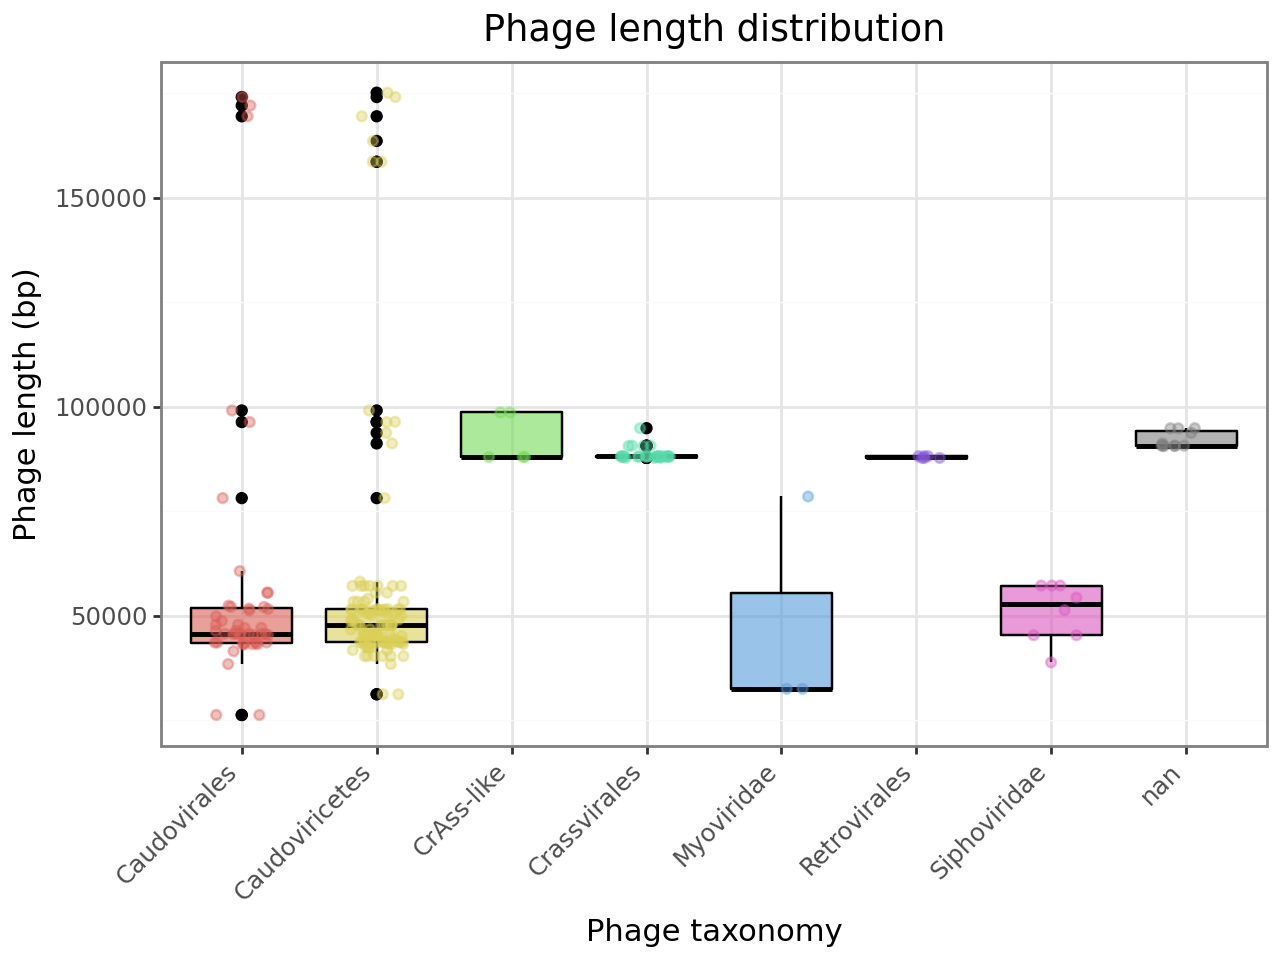

In [62]:
p_box = (
    # ggplot(blastn_filt[blastn_filt['spacerhost'] == 'Prevotella pectinovora'], aes(x='phagetaxonomy', y='phagelength', fill='phagetaxonomy')) +
    ggplot(blastn_filt, aes(x='phagetaxonomy', y='phagelength', fill='phagetaxonomy')) +
    geom_boxplot(alpha=0.6, color="black") +
    geom_jitter(aes(color='phagetaxonomy'), alpha=0.4, width=0.2) +
    # scale_x_discrete(limits=blastn_filt['category'].unique()) +
    # scale_y_continuous(breaks=list(range(0, int(blastn_filt['avgspacerlen'].max()) + 5, 5))) +
    theme_bw() +
    labs(
        title='Phage length distribution',
        x='Phage taxonomy',
        y='Phage length (bp)'
    ) +
    theme(axis_text_x=element_text(rotation=45, hjust=1), legend_position='none')    
)

display(p_box)

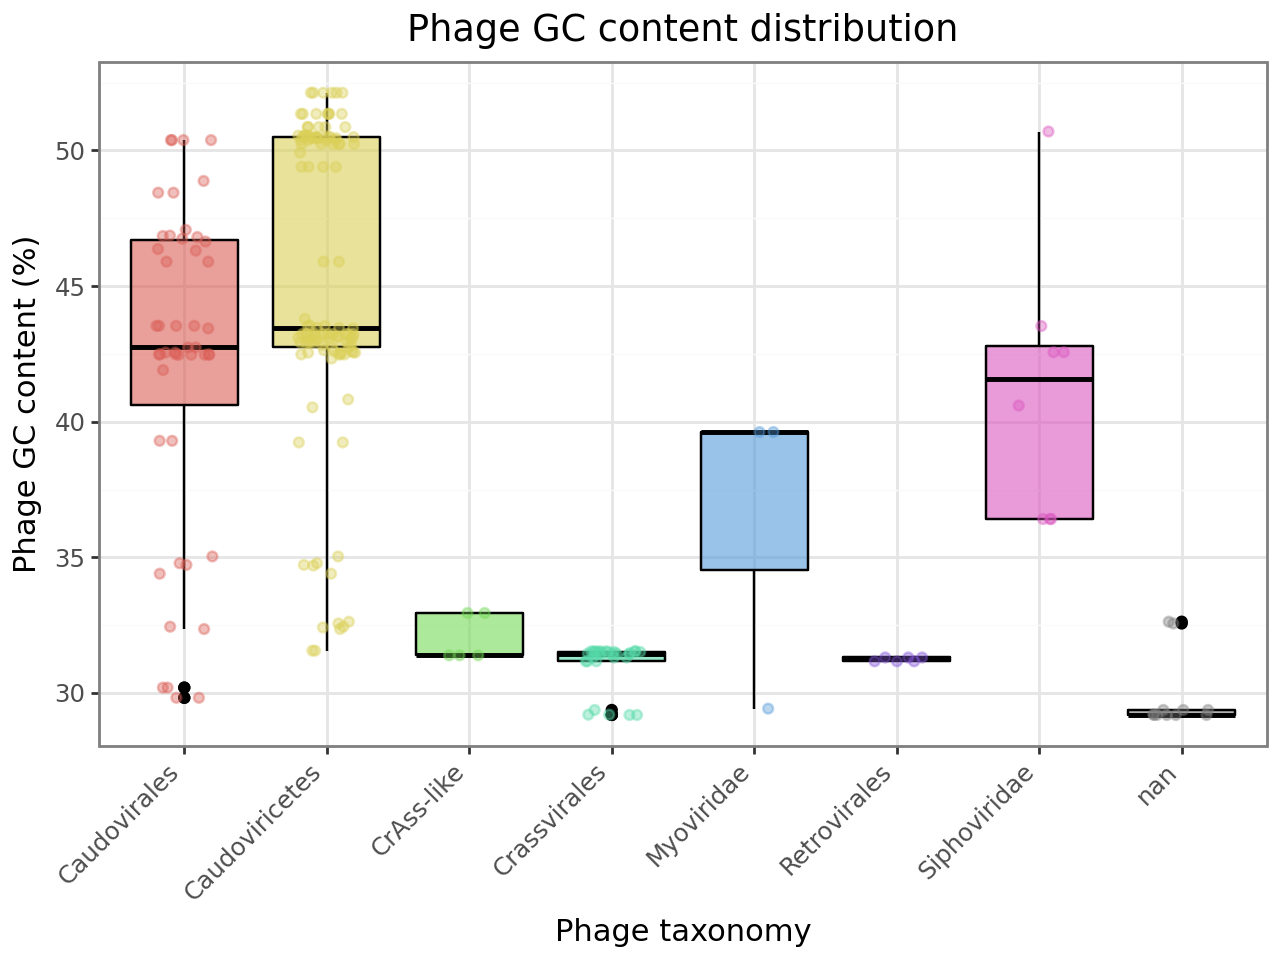

In [63]:
p_box = (
    # ggplot(blastn_filt[blastn_filt['spacerhost'] == 'Prevotella pectinovora'], aes(x='phagetaxonomy', y='phagecg', fill='phagetaxonomy')) +
    ggplot(blastn_filt, aes(x='phagetaxonomy', y='phagecg', fill='phagetaxonomy')) +
    geom_boxplot(alpha=0.6, color="black") +
    geom_jitter(aes(color='phagetaxonomy'), alpha=0.4, width=0.2) +
    # scale_x_discrete(limits=blastn_filt['category'].unique()) +
    # scale_y_continuous(breaks=list(range(0, int(blastn_filt['avgspacerlen'].max()) + 5, 5))) +
    theme_bw() +
    labs(
        title='Phage GC content distribution',
        x='Phage taxonomy',
        y='Phage GC content (%)'
    ) +
    theme(axis_text_x=element_text(rotation=45, hjust=1), legend_position='none')    
)

display(p_box)

/tmp/ipykernel_7811/2589541383.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


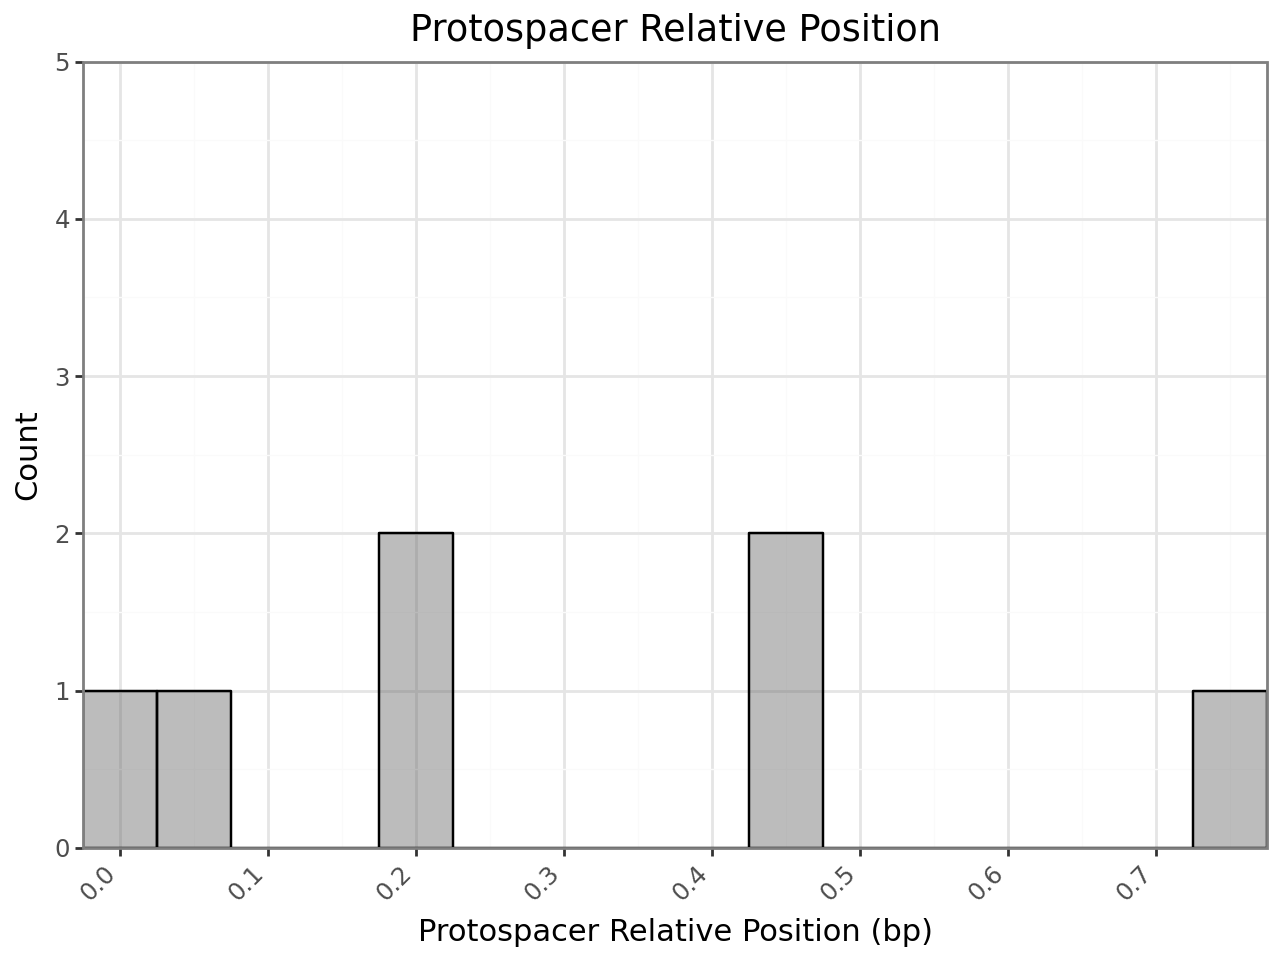

In [8]:
def calculate_relative_position(d, phage_length):
    """
    Calculate the relative position of a spacer within a phage genome.
    """

    d['relative_position'] = (d['phagestart'] + d['phageend']) / (2 * phage_length)
    return d

blastn_positions = calculate_relative_position(blastn_filt, blastn_filt['phagelength'])

# print(blastn_positions['relative_position'].describe())


p_freq = (
    ggplot(blastn_positions[blastn_positions['sequence_id'] == '572d304e-117a-467b-90ac-2c3195ca24b1'], aes(x='relative_position')) +
    geom_histogram(binwidth=0.05, position="identity", alpha=0.4, color="black") +
    # geom_density(alpha=0.6) +
    scale_y_continuous(limits=(0, 5), expand=(0, 0)) +
    scale_x_continuous(expand=(0, 0), breaks=np.round(np.arange(0.0, 1.05, 0.1), 2)) +
    theme_bw() +
    labs(title='Protospacer Relative Position',
        x='Protospacer Relative Position (bp)',
        y='Count') +
    theme(axis_text_x=element_text(rotation=45, hjust=1))
    )


display(p_freq)

Extract all ORF in the phage genome that overlap with the corresponding protospacer. 

In [ ]:
home_dir = Path('/home/unimelb.edu.au/rbengtsson/work/spacer_analysis/')
blastn_file = f"{home_dir}/phage/spacer_phageblastn_results.csv"

blastn_df = db_utils.read_table_from_db(blastn_file)
sequence_id_list = blastn_df['sequence_id'].unique().tolist()

out_dir = Path(f"/spacers_db/blastn_results/")
    
# run intersection in parallel
with ProcessPoolExecutor(max_workers=4) as executor:
    executor.map(PhageElement.get_intersection, sequence_id_list, [blastn_file]*len(sequence_id_list), [out_dir]*len(sequence_id_list))